# Mutual Fund Exploratory Data Analysis

**Intern:** Nuha Pathan 
**Organization:** Bluestock Fintech  
**Task:** Exploratory Data Analysis (EDA)

---

## Objective

The objective of this notebook is to analyze the mutual fund datasets and generate meaningful business insights using visualizations.

In [10]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sb

import plotly
import plotly.express as px
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "iframe_connected"

import kaleido

from sqlalchemy import create_engine
engine = create_engine("sqlite:///../sql/bluestock_mf.db")

# 1. NAV Trend Analysis
### Objective

Analyze the daily Net Asset Value (NAV) movement of all mutual fund schemes from 2022 to 2026. The visualization highlights the overall trend while marking the 2023 bull market and the 2024 market correction.

In [11]:
query = """SELECT dd.date, df.scheme_name, fn.nav 
            FROM fact_nav fn 
            INNER JOIN dim_fund df ON fn.amfi_code = df.amfi_code 
            INNER JOIN dim_date dd ON fn.date_id = dd.date_id 
            ORDER BY dd.date;"""
nav_df = pd.read_sql(query, engine)
print(nav_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         46000 non-null  str    
 1   scheme_name  46000 non-null  str    
 2   nav          46000 non-null  float64
dtypes: float64(1), str(2)
memory usage: 1.1 MB
None


In [8]:
print("Duplicate records : ",nav_df.duplicated().sum())

Duplicate records :  0


In [9]:
print("Number of schemes : ",nav_df["scheme_name"].nunique())

Number of schemes :  40


In [10]:
print("Starting from : ",nav_df["date"].min())
print("Till : ",nav_df["date"].max())

Starting from :  2022-01-03 00:00:00.000000
Till :  2026-05-29 00:00:00.000000


In [12]:
fig = px.line(nav_df, x="date", y="nav", color="scheme_name", title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.15, line_width=0, annotation_text="2023 Bull Run",
    annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.15, line_width=0, annotation_text="2024 Market Correction",
    annotation_position="top left")
fig.update_layout( template="plotly_white", xaxis_title="Date", yaxis_title="NAV (₹)", legend_title="Scheme Name", height=700, hovermode="x unified")
fig.write_image("../reports/charts/chart_01_nav_trend.png")
fig.show()

# 2. AUM Growth Analysis
### Objective

Analyze the annual Assets Under Management (AUM) growth of mutual fund houses from 2022 to 2025.
This visualization compares the year-wise AUM of different fund houses while highlighting SBI Mutual Fund's market leadership with an AUM of approximately ₹12.5 lakh crore in 2025.

In [13]:
query = """SELECT  dd.year, fa.fund_house, fa.aum_lakh_crore
            FROM fact_aum fa
            JOIN dim_date dd ON fa.date_id = dd.date_id
            WHERE dd.year BETWEEN 2022 AND 2025
            ORDER BY dd.year, fa.fund_house;"""
aum_df = pd.read_sql(query,engine)
print(aum_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            90 non-null     int64  
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.2 KB
None


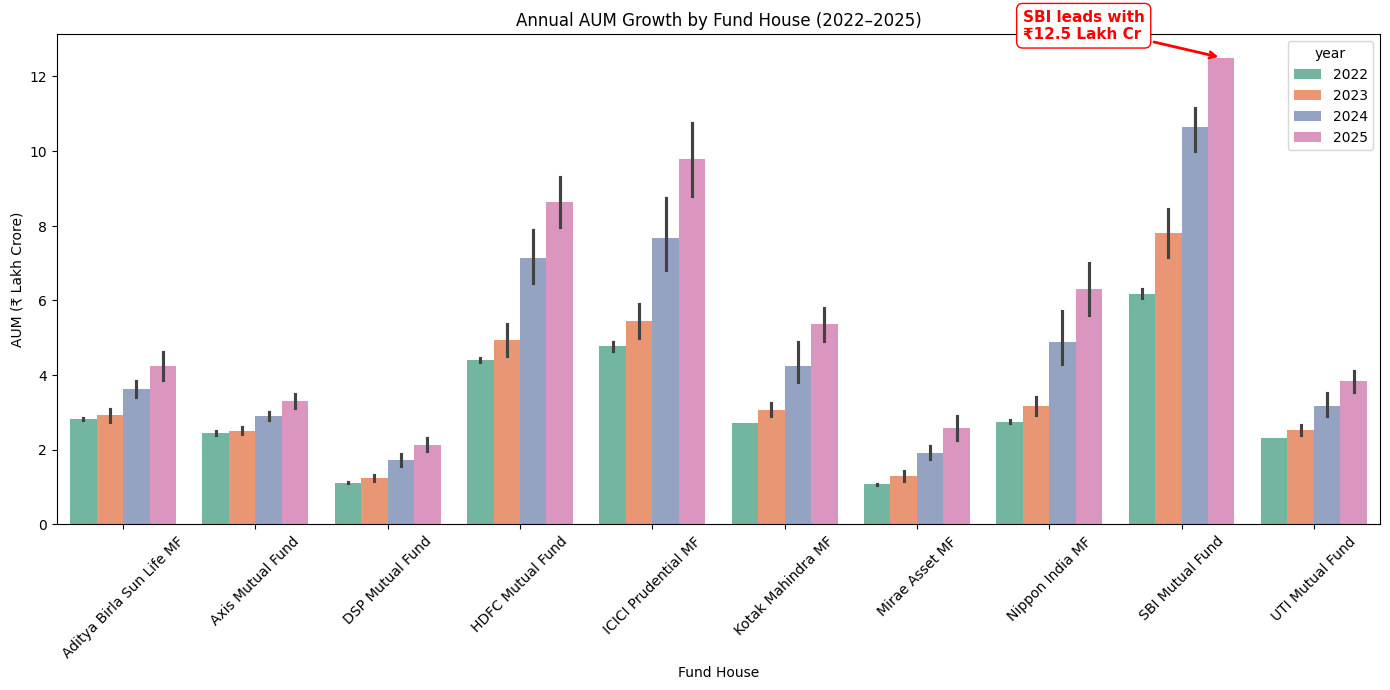

In [8]:
plt.figure(figsize=(14,7))
ax = sb.barplot(data=aum_df, x="fund_house", y="aum_lakh_crore", hue="year", palette="Set2")
ax.annotate("SBI leads with\n₹12.5 Lakh Cr", xy=(8.3, 12.5), xytext=(6.8, 13.0),      
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    fontsize=11,
    color="red",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="red")
)
plt.title("Annual AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/charts/chart_02_aum_growth.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The grouped bar chart shows a steady increase in Assets Under Management (AUM) across all major fund houses between 2022 and 2025. SBI Mutual Fund consistently maintained the highest AUM, reaching approximately ₹12.5 lakh crore in 2025, reinforcing its dominant position in the Indian mutual fund industry. ICICI Prudential and HDFC Mutual Fund also demonstrated strong year-over-year growth.

# 3. Monthly SIP Trend
### Objective

Analyze the monthly SIP (Systematic Investment Plan) inflows from January 2022 to December 2025 to understand the growth in retail investor participation and highlight the all-time high SIP inflow of ₹31,002 crore in December 2025.

In [14]:
query = """SELECT month, sip_inflow_crore
            FROM monthly_sip_inflows
            ORDER BY month;"""
sip_df = pd.read_sql(query,engine)
sip_df["month"] = pd.to_datetime(sip_df["month"])
print(sip_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             48 non-null     datetime64[us]
 1   sip_inflow_crore  48 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 900.0 bytes
None


In [15]:
fig = px.line(sip_df, x="month", y="sip_inflow_crore", title="Monthly SIP Inflows (Jan 2022 – Dec 2025)", markers=True)
max_row = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=max_row["sip_inflow_crore"],
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="red",
    bgcolor="white",
    bordercolor="red",
    font=dict(color="red", size=12)
)
fig.update_layout(template="plotly_white", xaxis_title="Month", yaxis_title="SIP Inflow (₹ Crore)", height=650)
fig.write_image("../reports/charts/chart_03_monthly_sip.png")
fig.show()

### Observation

Monthly SIP inflows exhibited a consistent upward trend between January 2022 and December 2025, reflecting increasing retail investor participation in mutual funds. The highest monthly SIP inflow of approximately ₹31,002 crore was recorded in December 2025, indicating strong investor confidence and sustained growth in systematic investments.

# 4. Category Inflow Heatmap
### Objective

Analyze the monthly net inflows across different mutual fund categories to identify seasonal investment patterns, investor preferences, and periods of high or low fund inflows between 2022 and 2025.

In [15]:
query = "SELECT month,category, net_inflow_crore FROM category_inflows ORDER BY month, category;"
category_df = pd.read_sql(query,engine)
category_df["month"] = pd.to_datetime(category_df["month"])
print(category_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[us]
 1   category          144 non-null    str           
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 3.5 KB
None


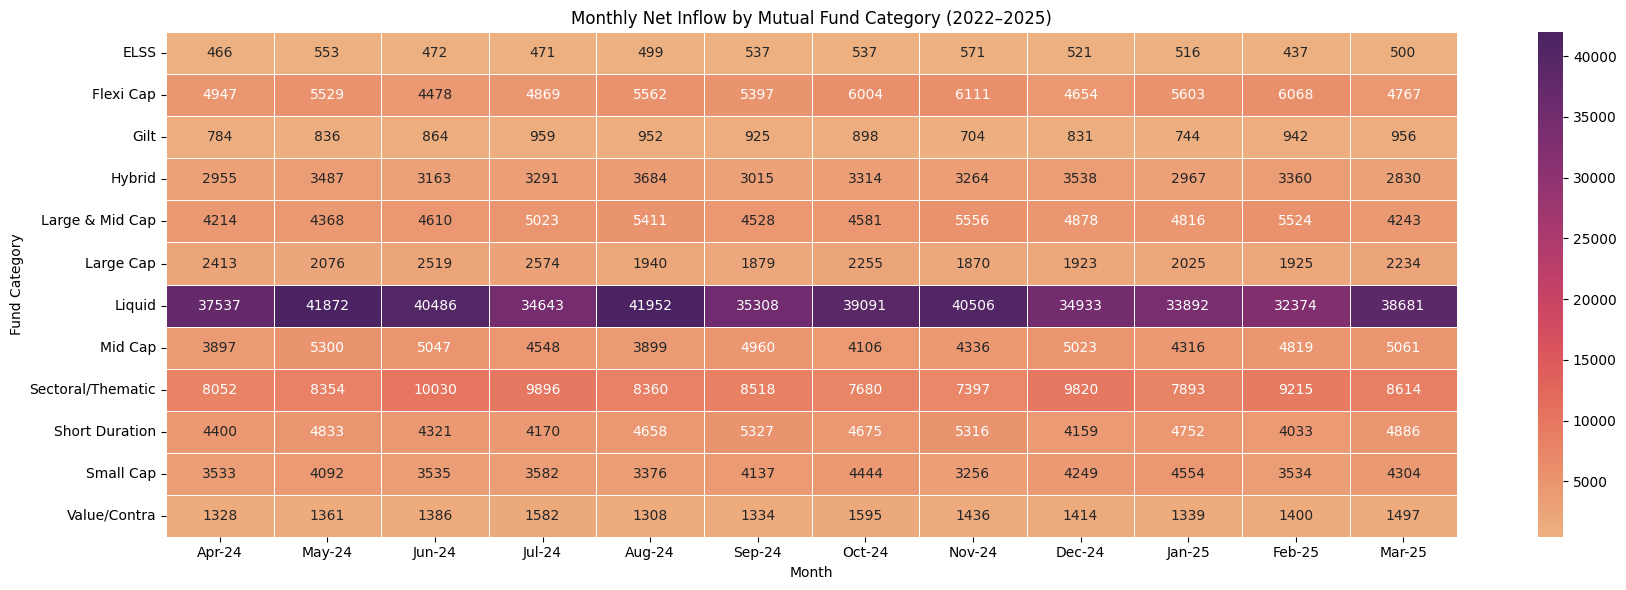

In [16]:
heatmap_data = category_df.pivot(index="category", columns="month", values="net_inflow_crore")
heatmap_data.columns = heatmap_data.columns.strftime("%b-%y")

plt.figure(figsize=(18,6))

sb.heatmap(heatmap_data, cmap="flare", linewidths=0.5, linecolor="white", annot=True, fmt=".0f")

plt.title("Monthly Net Inflow by Mutual Fund Category (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig("../reports/charts/chart_04_category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The heatmap reveals clear variations in monthly net inflows across different mutual fund categories. Equity-oriented categories consistently attracted higher inflows than other categories, while some categories experienced lower or fluctuating investments during certain months. The color intensity helps identify periods of strong investor preference and changing market sentiment between 2022 and 2025.

# 5. Investor Demographics
### Objective

Analyze the demographic profile of mutual fund investors by examining the distribution of different age groups, comparing SIP investment amounts across age groups, and evaluating the overall gender distribution of investors.

## Age Group Distribution (Pie Chart)
### Objective

Understand the proportion of investors across different age groups to identify the most active age segment participating in mutual fund investments.

In [16]:
query = """SELECT age_group, COUNT(*) AS investors
            FROM fact_transactions
            GROUP BY age_group
            ORDER BY investors DESC;"""
age_df = pd.read_sql(query,engine)
print(age_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age_group  5 non-null      str  
 1   investors  5 non-null      int64
dtypes: int64(1), str(1)
memory usage: 212.0 bytes
None


In [17]:
fig = px.pie(age_df, names="age_group", values="investors", title="Investor Distribution by Age Group", 
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white", height=650)
fig.write_image("../reports/charts/chart_05_age_distribution.png")
fig.show()

### Observation

The investor base is concentrated in the middle-age segments, indicating that individuals in their primary earning years contribute the largest share of mutual fund investments. Younger and senior investor groups represent comparatively smaller proportions.

## SIP Amount by Age Group (Box Plot)
### Objective

Compare the distribution of transaction amounts across different age groups to identify which segments invest larger amounts and to observe the variability in investment behavior.

In [19]:
query = """SELECT age_group, amount_inr
        FROM fact_transactions
        WHERE transaction_type = 'SIP';"""
sip_age_df = pd.read_sql(query,engine)
print(sip_age_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19716 entries, 0 to 19715
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age_group   19716 non-null  str  
 1   amount_inr  19716 non-null  int64
dtypes: int64(1), str(1)
memory usage: 308.2 KB
None


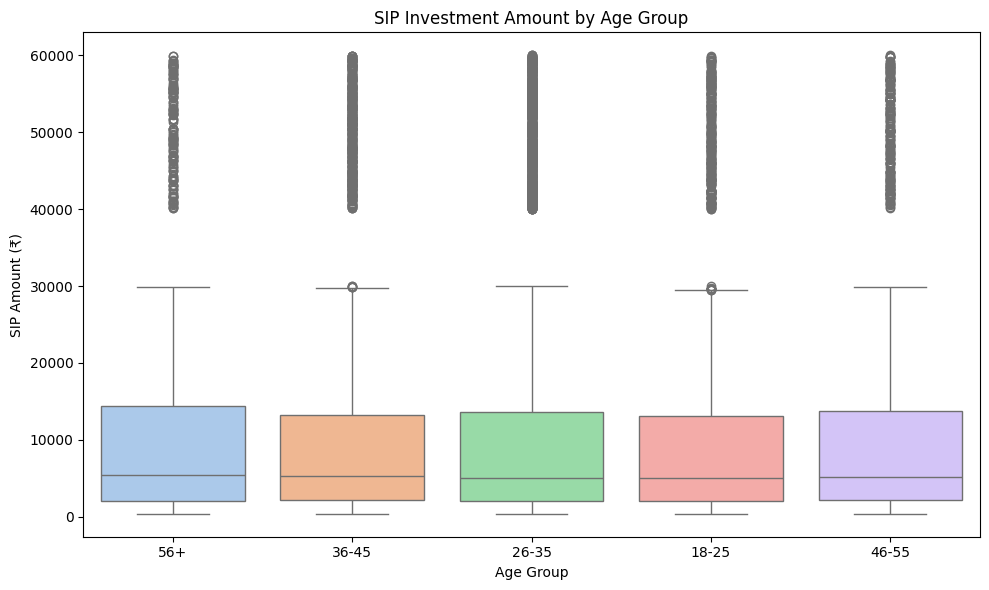

In [32]:
plt.figure(figsize=(10,6))

sb.boxplot(data=sip_age_df, x="age_group", y="amount_inr", hue="age_group", palette="pastel", legend=False)

plt.title("SIP Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig("../reports/charts/chart_06_sip_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The box plot compares SIP investment amounts across different age groups. It highlights differences in median investment values, variability, and the presence of outliers, providing insight into how investment behavior varies among different investor age segments.

## Gender Split
### Objective

Visualize the gender-wise distribution of mutual fund investors to understand the participation of different genders in mutual fund investments.

In [18]:
query = """SELECT gender,
            COUNT(*) AS investors
            FROM fact_transactions
            GROUP BY gender
            ORDER BY investors DESC;"""
gender_df = pd.read_sql(query, engine)
print(gender_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   gender     2 non-null      str  
 1   investors  2 non-null      int64
dtypes: int64(1), str(1)
memory usage: 164.0 bytes
None


In [19]:
fig = px.pie(gender_df,names="gender", values="investors", title="Gender Distribution of Mutual Fund Investors",
    color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textposition="inside",textinfo="percent+label")
fig.update_layout(template="plotly_white", height=650)
fig.write_image("../reports/charts/chart_07_gender_distribution.png")

fig.show()

# 6. Geographic Distribution

## Geographic Distribution (State-wise SIP Amount)
### Objective

Analyze the total SIP investment amount across different states to identify regions contributing the highest systematic investment inflows.

In [21]:
query = """SELECT state, SUM(amount_inr) AS total_sip
            FROM fact_transactions
            WHERE transaction_type = 'SIP'
            GROUP BY state
            ORDER BY total_sip DESC;"""
state_df = pd.read_sql(query, engine)
print(state_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   state      12 non-null     str  
 1   total_sip  12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 324.0 bytes
None


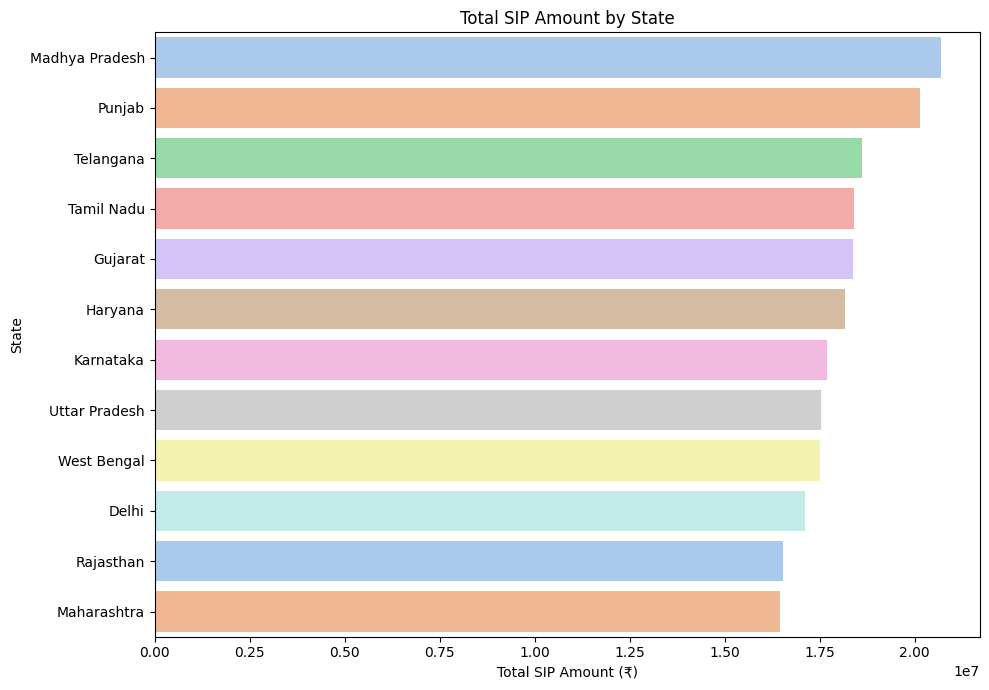

In [28]:
plt.figure(figsize=(10,7))

sb.barplot(data=state_df, x="total_sip", y="state", palette="pastel", hue="state", legend=False)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../reports/charts/chart_08_geographic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The horizontal bar chart highlights the states contributing the highest SIP investment amounts. A few states account for a significant share of total SIP inflows, indicating stronger mutual fund participation and higher investment activity in those regions.

## T30 vs B30 City Tier
### Objective

Compare investor participation between T30 and B30 cities to understand the geographical spread of mutual fund investments.

In [20]:
query = """SELECT city_tier, COUNT(*) AS investors
            FROM fact_transactions
            GROUP BY city_tier;"""
tier_df = pd.read_sql(query, engine)
print(tier_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   city_tier  2 non-null      str  
 1   investors  2 non-null      int64
dtypes: int64(1), str(1)
memory usage: 164.0 bytes
None


In [21]:
fig = px.pie(tier_df, names="city_tier", values="investors", title="Investor Distribution: T30 vs B30 Cities",
    color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white", height=650)
fig.write_image("../reports/charts/chart_09_t30_b30.png.png")
fig.show()

### Observation

The pie chart compares investor participation between T30 and B30 cities. It illustrates whether mutual fund investments remain concentrated in major metropolitan regions or are expanding into emerging cities, reflecting the geographical diversification of retail investors.

# 7. Folio Count Growth
### Objective

Analyze the growth in mutual fund folio counts across investor categories to understand how investor participation has evolved over time.

In [22]:
query = "SELECT *FROM industry_folio_count ORDER BY month;"
folio_df = pd.read_sql(query,engine)
folio_df["month"] = pd.to_datetime(folio_df["month"])
print(folio_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[us]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.1 KB
None


In [23]:
fig = px.line(folio_df, x="month",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    title="Growth in Mutual Fund Folio Counts (2022–2025)",
    markers=True)
fig.update_layout(template="plotly_white", xaxis_title="Month", yaxis_title="Folio Count (Crore)", legend_title="Category", height=650)
fig.write_image("../reports/charts/chart_10_folio_growth.png")
fig.show()

### Observation

Equity mutual funds exhibited the strongest folio growth throughout the analysis period, indicating increasing investor participation in equity-oriented investments. Hybrid and debt categories experienced comparatively moderate growth, while other categories maintained relatively stable folio counts over time.

# 8. NAV Correlation Matrix
### Objective

Analyze the correlation between NAV movements of selected mutual fund schemes to identify funds that exhibit similar or contrasting performance trends.

In [33]:
query = """SELECT df.scheme_name, dd.date AS date, fn.nav
            FROM fact_nav fn
            JOIN dim_date dd ON fn.date_id = dd.date_id
            JOIN dim_fund df ON fn.amfi_code = df.amfi_code
            WHERE fn.amfi_code IN (
                SELECT amfi_code
                FROM fact_nav
                GROUP BY amfi_code
                ORDER BY AVG(nav) DESC
                LIMIT 10)"""
nav_df = pd.read_sql(query, engine)
nav_df["date"] = pd.to_datetime(nav_df["date"])
print(nav_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   scheme_name  11500 non-null  str           
 1   date         11500 non-null  datetime64[us]
 2   nav          11500 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 269.7 KB
None


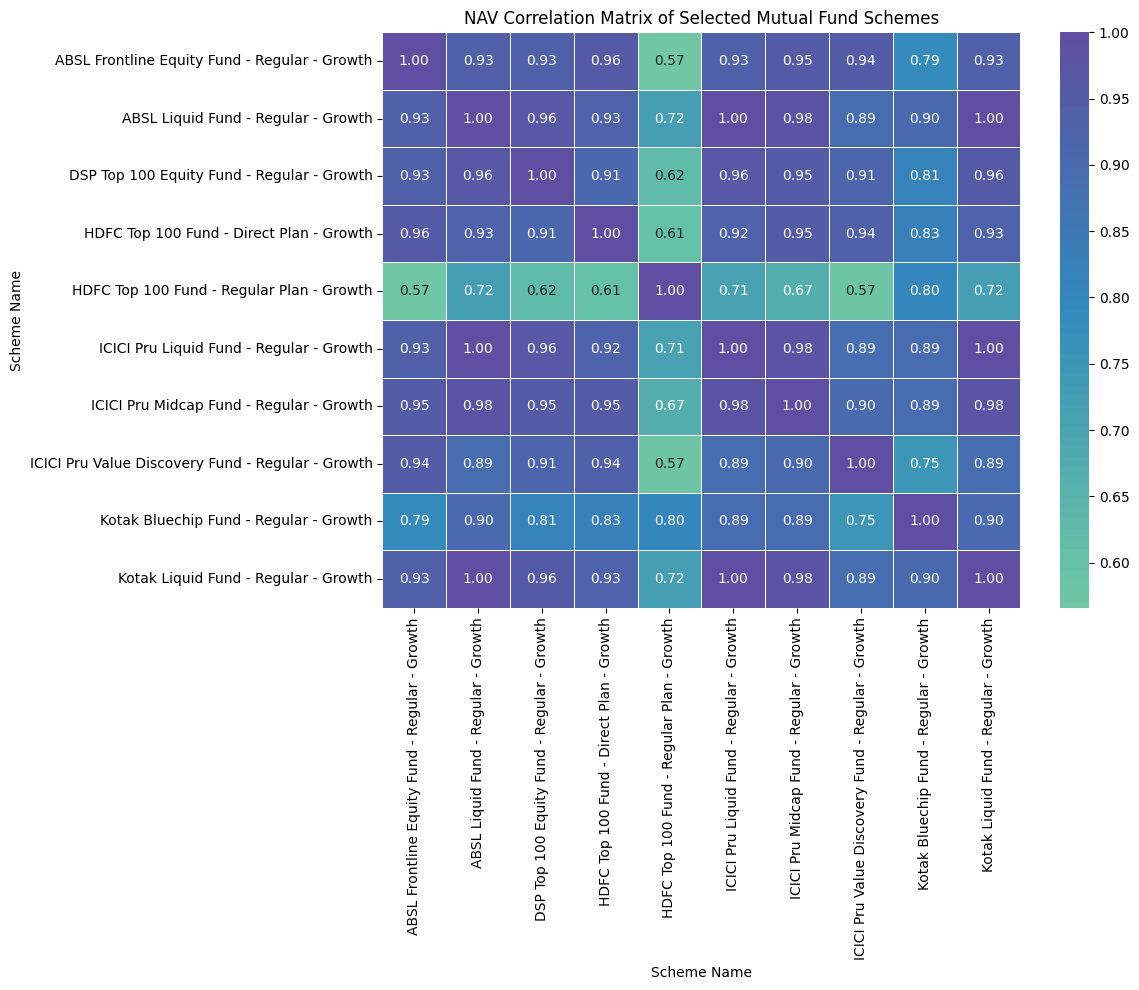

In [34]:
nav_pivot = nav_df.pivot(index="date", columns="scheme_name", values="nav")
correlation_matrix = nav_pivot.corr()

plt.figure(figsize=(12,10))

sb.heatmap(correlation_matrix, annot=True, cmap="Spectral", center=0, linewidths=0.5, fmt=".2f")

plt.title("NAV Correlation Matrix of Selected Mutual Fund Schemes")
plt.xlabel("Scheme Name")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig("../reports/charts/chart_11_nav_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

### Data Selection

To improve readability and focus the analysis on the most significant schemes, only the top 10 mutual fund schemes based on average NAV were selected. This avoids overcrowding in the correlation matrix while enabling meaningful comparison of NAV movement patterns.

### Observation

The NAV correlation matrix illustrates the relationship between the price movements of the selected mutual fund schemes. Most schemes exhibit positive correlations, indicating similar responses to market conditions, while lower correlation values suggest relatively independent performance among certain schemes.

# 9. Sector Allocation
### Objective

Visualize the overall sector-wise allocation of equity mutual fund portfolios by aggregating sector weights across all portfolio holdings.

In [24]:
query = """SELECT sector,
            SUM(weight_pct) AS total_weight
            FROM portfolio_holdings
            GROUP BY sector
            ORDER BY total_weight DESC;"""
sector_df = pd.read_sql(query, engine)
print(sector_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sector        14 non-null     str    
 1   total_weight  14 non-null     float64
dtypes: float64(1), str(1)
memory usage: 356.0 bytes
None


In [25]:
fig = px.pie(sector_df, names="sector", values="total_weight", title="Sector Allocation Across Equity Mutual Fund Portfolios", hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white", height=700)
fig.write_image("../reports/charts/chart_12_sector_allocation.png")
fig.show()

### Observation

The donut chart illustrates the aggregate allocation of mutual fund portfolios across different sectors. Financial services, technology, and other major sectors account for a significant share of the overall portfolio weight, highlighting the sectors that receive the highest investment exposure across equity mutual funds.

# 10. Payment Mode Distribution (Pie Chart)
### Objective

Analyze the distribution of payment modes used by investors while making mutual fund investments.

In [26]:
query = """SELECT payment_mode,
            COUNT(*) AS count
            FROM fact_transactions
            GROUP BY payment_mode
            ORDER BY count DESC;"""
payment_df = pd.read_sql(query, engine)
print(payment_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   payment_mode  4 non-null      str  
 1   count         4 non-null      int64
dtypes: int64(1), str(1)
memory usage: 196.0 bytes
None


In [27]:
fig = px.pie(payment_df, names="payment_mode", values="count", title="Distribution of Payment Modes",
    color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white", height=650)
fig.write_image("../reports/charts/chart_13_payment_mode.png")
fig.show()

### Observation

The chart illustrates the preferred payment methods adopted by investors. The Net Banking payment mode indicates the most commonly used channel for mutual fund transactions.

# 11. KYC Status Distribution (Donut Chart)
### Objective

Examine the proportion of investors with completed and pending KYC verification.

In [28]:
query = """SELECT kyc_status,
            COUNT(*) AS investors
            FROM fact_transactions
            GROUP BY kyc_status;"""
kyc_df = pd.read_sql(query, engine)
print(kyc_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   kyc_status  2 non-null      str  
 1   investors   2 non-null      int64
dtypes: int64(1), str(1)
memory usage: 164.0 bytes
None


In [29]:
fig = px.pie(kyc_df, names="kyc_status", values="investors", hole=0.4, title="KYC Status Distribution",
    color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white", height=650)
fig.write_image("../reports/charts/chart_14_kyc_status.png")
fig.show()

### Observation

The majority of investors have completed KYC verification, indicating regulatory compliance and readiness for investment transactions.

# 12. Transaction Type Distribution (Bar Chart)

### Objective

Compare the frequency of different mutual fund transaction types.

In [41]:
query = """SELECT transaction_type,
            COUNT(*) AS transactions
            FROM fact_transactions
            GROUP BY transaction_type
            ORDER BY transactions DESC;"""
transaction_df = pd.read_sql(query, engine)
print(transaction_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_type  3 non-null      str  
 1   transactions      3 non-null      int64
dtypes: int64(1), str(1)
memory usage: 180.0 bytes
None


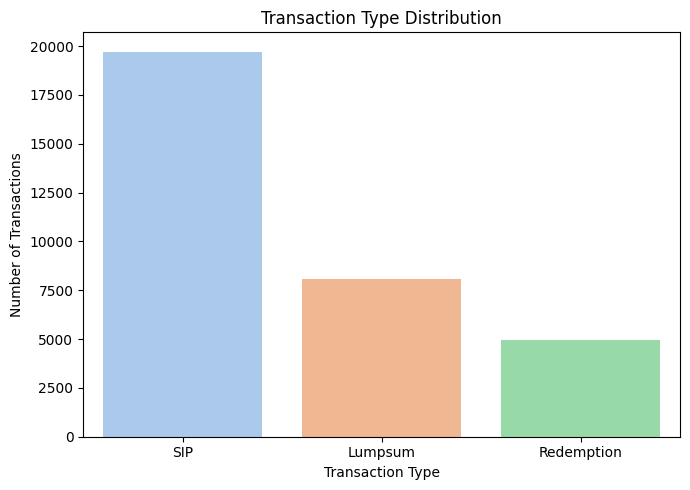

In [42]:
plt.figure(figsize=(7,5))

sb.barplot(data=transaction_df, x="transaction_type", y="transactions", hue="transaction_type", palette="pastel", legend=False)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("../reports/charts/chart_15_transaction_type.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

SIP transactions constitute the largest share of mutual fund activities, reflecting the popularity of systematic investment plans among retail investors.

# 13. Annual Income Group Analysis (Histogram)

### Objective

Analyze the distribution of investors across different annual income groups.

In [43]:
query = "SELECT annual_income_lakh FROM fact_transactions;"

income_df = pd.read_sql(query, engine)
print(income_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   annual_income_lakh  32778 non-null  float64
dtypes: float64(1)
memory usage: 256.2 KB
None


In [44]:
bins = [0, 5, 10, 20, 50, 100]
labels = ["0-5 Lakh", "5-10 Lakh", "10-20 Lakh", "20-50 Lakh", "50+ Lakh"]

income_df["income_group"] = pd.cut(
    income_df["annual_income_lakh"],
    bins=bins,
    labels=labels)

income_summary = (
    income_df["income_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

income_summary.columns = ["income_group", "count"]

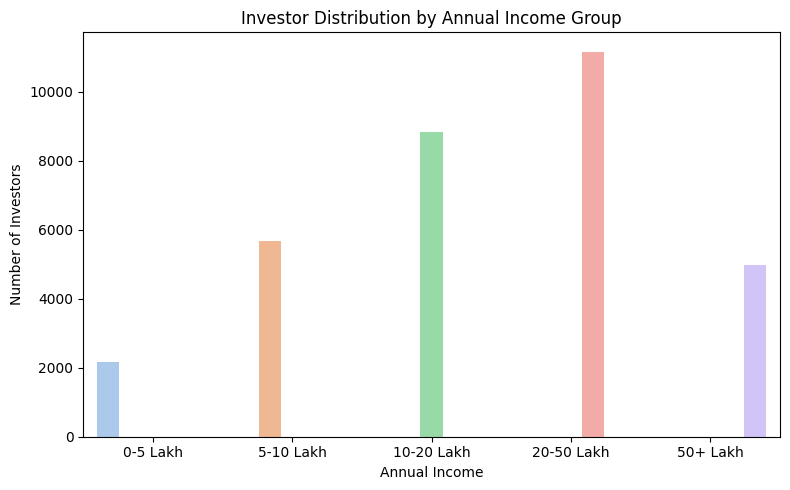

In [45]:
plt.figure(figsize=(8,5))

sb.barplot(data=income_summary, x="income_group", y="count", hue="income_group", palette="pastel", legend=False)

plt.title("Investor Distribution by Annual Income Group")
plt.xlabel("Annual Income")
plt.ylabel("Number of Investors")
plt.tight_layout()
plt.savefig("../reports/charts/chart_16_income_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The chart highlights the distribution of investors across different annual income brackets, providing insight into the primary income segments participating in mutual fund investments.